<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.0 MB/s eta 0:00:00


In [2]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model

#Grupo México

In [4]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_18482/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [5]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [6]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [7]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

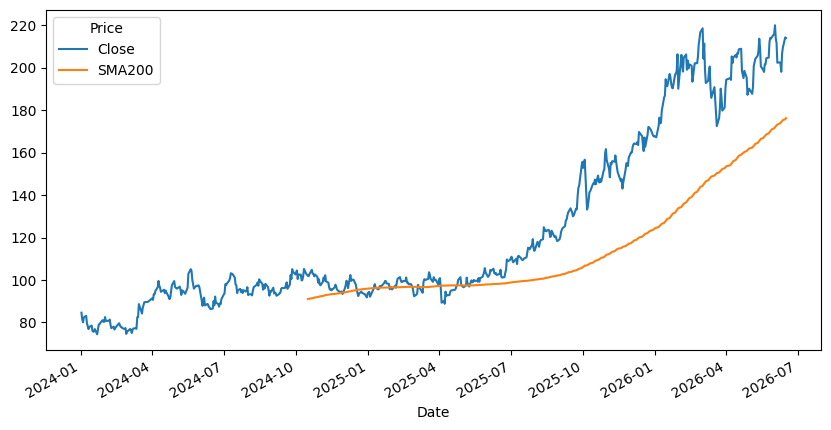

In [8]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [9]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [10]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

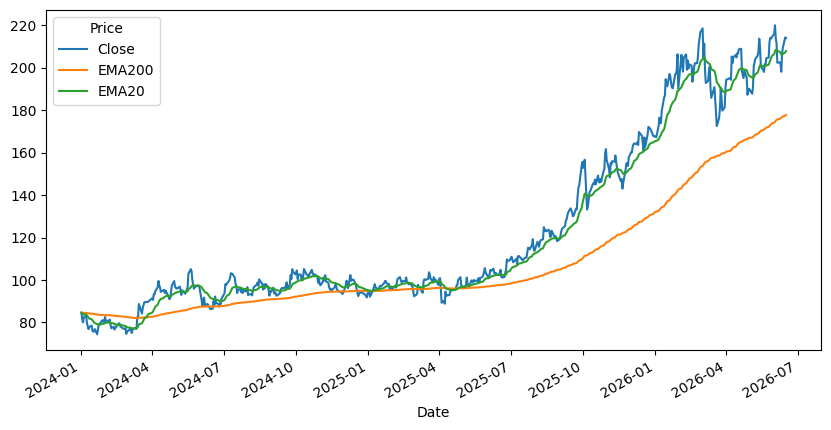

In [11]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

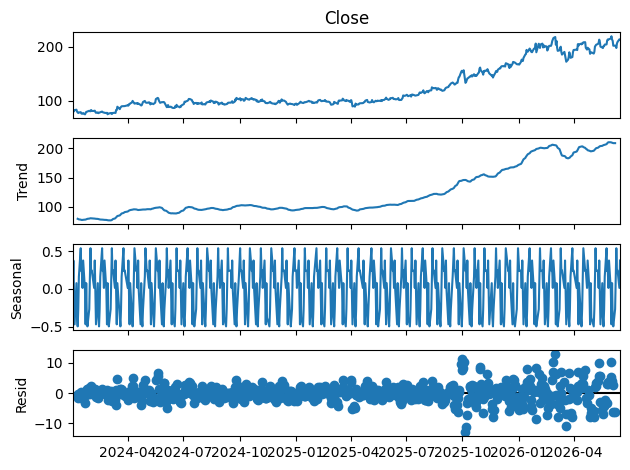

In [12]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

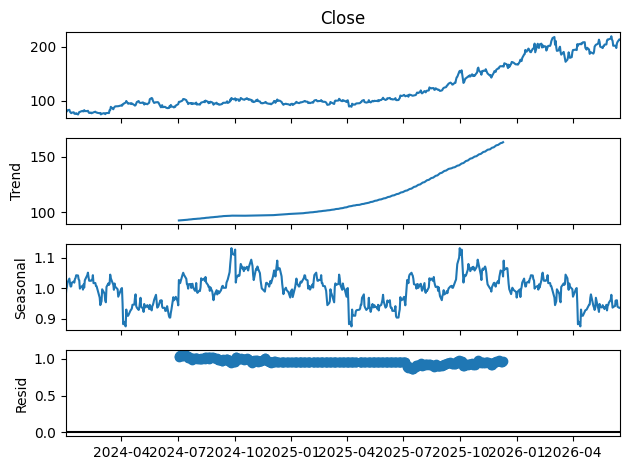

In [13]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [14]:
#Obtener datos
precios = df['Close']

In [15]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-10   -0.018762
2026-06-11    0.041888
2026-06-12    0.013805
2026-06-15    0.022810
2026-06-16   -0.001448
Name: Rendimientos_Log, Length: 614, dtype: float64


In [16]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-10   -0.018762
2026-06-11    0.041888
2026-06-12    0.013805
2026-06-15    0.022810
2026-06-16   -0.001448
Name: Rendimientos_Log, Length: 613, dtype: float64


In [17]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [18]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [19]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [20]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0223 = 2.2260 %
Volatilidad anualizada: 0.3534 = 35.3360 %


##Average True Range

In [21]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [22]:
print(high_low)

Date
2024-01-03    3.811026
2024-01-04    2.643276
2024-01-05    6.381882
2024-01-08    2.570863
2024-01-09    4.200276
                ...   
2026-06-10    6.440002
2026-06-11    8.629990
2026-06-12    6.639999
2026-06-15    7.980011
2026-06-16    6.010010
Length: 613, dtype: float64


In [23]:
print(high_close)

Date
2024-01-03          NaN
2024-01-04     0.117682
2024-01-05     6.046948
2024-01-08     0.887126
2024-01-09     0.253460
                ...    
2026-06-10     1.240005
2026-06-11     9.229996
2026-06-12     6.589996
2026-06-15    10.650009
2026-06-16     4.820007
Length: 613, dtype: float64


In [24]:
print(low_close)

Date
2024-01-03         NaN
2024-01-04    2.525594
2024-01-05    0.334934
2024-01-08    1.683737
2024-01-09    3.946816
                ...   
2026-06-10    5.199997
2026-06-11    0.600006
2026-06-12    0.050003
2026-06-15    2.669998
2026-06-16    1.190002
Length: 613, dtype: float64


In [25]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [26]:
print(true_range)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-10     6.440002
2026-06-11     9.229996
2026-06-12     6.639999
2026-06-15    10.650009
2026-06-16     6.010010
Length: 613, dtype: float64


In [27]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [28]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [29]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-10  202.990005  196.550003  198.000000       7.551677
2026-06-11  207.229996  198.600006  206.470001       7.671557
2026-06-12  213.059998  206.419998  209.339996       7.597874
2026-06-15  219.990005  212.009995  214.169998       7.815884
2026-06-16  218.990005  212.979996  213.860001       7.686893


In [30]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.2510


In [31]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 67.4821


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [32]:
#Obtener datos
precios = df['Close']

In [33]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [34]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.2763
Valor p: 0.9762
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9762295795153861)

####Diferenciando

In [35]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [36]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412163
2024-01-05    2.308342
2024-01-08    0.778496
2024-01-09   -3.611877
2024-01-10   -1.213013
Name: Close, dtype: float64


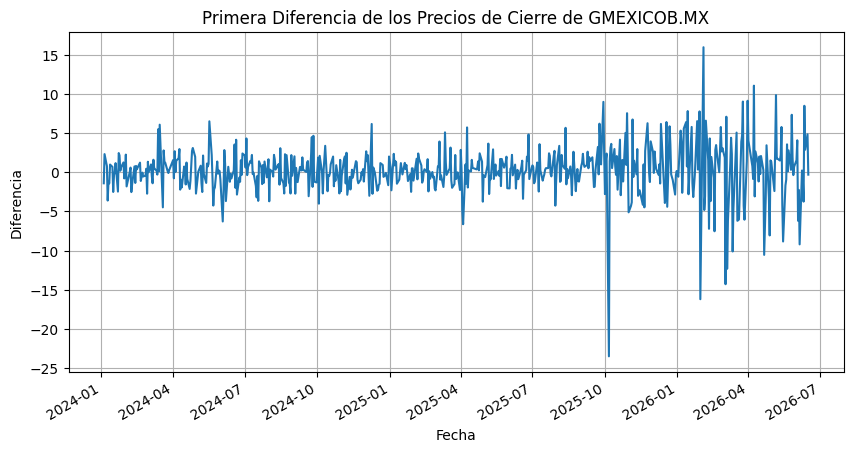

In [37]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [38]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -27.0717
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

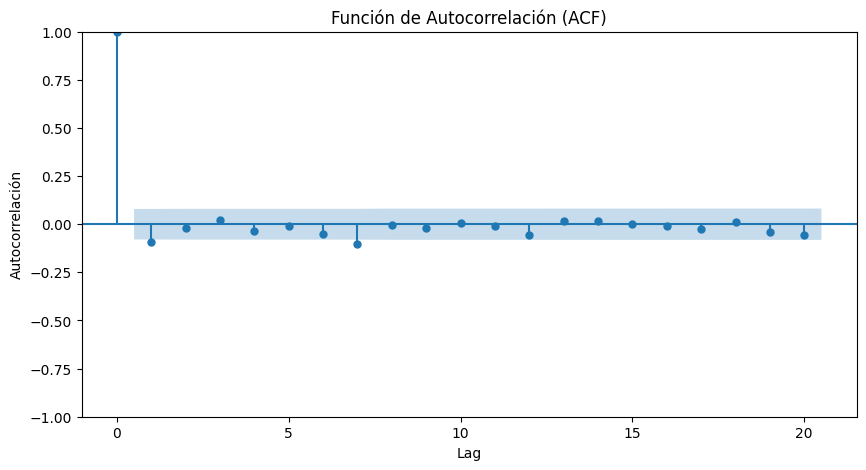

In [39]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

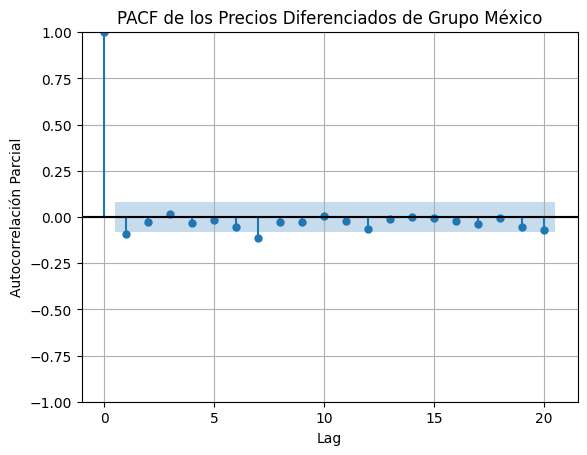

In [40]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [41]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-10   -0.018762
2026-06-11    0.041888
2026-06-12    0.013805
2026-06-15    0.022810
2026-06-16   -0.001448
Name: Rendimientos_Log, Length: 613, dtype: float64


In [42]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
2024-01-10   -0.015367
                ...   
2026-06-10   -0.018762
2026-06-11    0.041888
2026-06-12    0.013805
2026-06-15    0.022810
2026-06-16   -0.001448
Name: Rendimientos_Log, Length: 612, dtype: float64


In [43]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -26.9650
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

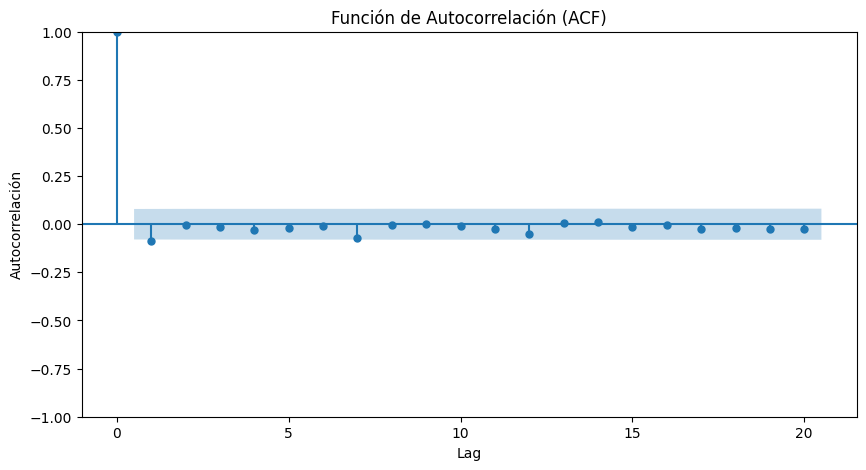

In [44]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

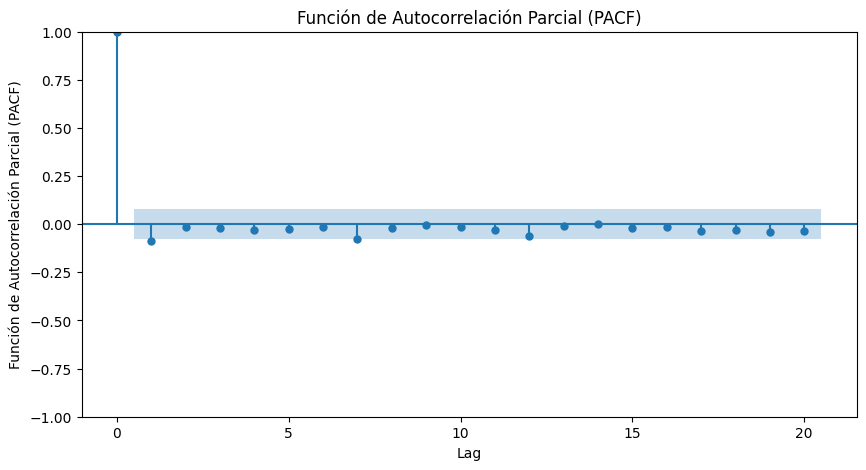

In [45]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [46]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  612
Model:                          ARIMA   Log Likelihood                1461.819
Date:                Tue, 16 Jun 2026   AIC                          -2919.638
Time:                        19:28:25   BIC                          -2910.805
Sample:                             0   HQIC                         -2916.203
                                - 612                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      1.702      0.089      -0.000       0.003
sigma2         0.0005   1.51e-05     32.555      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   4.74   Jarque-

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [47]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 7.6048834397336265
p-value: 0.6673690005273821


In [48]:
for orden in [(0,0,0),(1,0,0),(0,0,1),(1,0,1)]:
  modelo = ARIMA(df['Rendimientos_Log'].dropna(),order=orden)
  resultado = modelo.fit()

  print(orden, resultado.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/di

(0, 0, 0) -2919.6384465703795
(1, 0, 0) -2922.373677106737


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 1) -2922.4826295438897


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(1, 0, 1) -2920.5631046220487


In [49]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,1))

resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  612
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1464.241
Date:                Tue, 16 Jun 2026   AIC                          -2922.483
Time:                        19:28:29   BIC                          -2909.232
Sample:                             0   HQIC                         -2917.329
                                - 612                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      1.871      0.061   -7.51e-05       0.003
ma.L1         -0.0885      0.037     -2.377      0.017      -0.161      -0.016
sigma2         0.0005   1.55e-05     31.492      0.0

In [50]:
residuos = resultado.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.43647033544624514
Lag=10: p-value=0.77232993026278
Lag=15: p-value=0.9321790909730883
Lag=20: p-value=0.9775325774714335


In [51]:
residuos = resultado.resid

In [52]:
garch = arch_model(
    residuos,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

resultado_garch = garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 47358.46808850455
Iteration:      2,   Func. Count:     11,   Neg. LLF: -1012.5457593026072
Iteration:      3,   Func. Count:     19,   Neg. LLF: -1247.5569211578998
Iteration:      4,   Func. Count:     26,   Neg. LLF: -727.8966606737963
Iteration:      5,   Func. Count:     34,   Neg. LLF: -1459.276654286945
Iteration:      6,   Func. Count:     39,   Neg. LLF: -1471.3605797182101
Iteration:      7,   Func. Count:     43,   Neg. LLF: -1471.360538822642
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1471.3605797167675
            Iterations: 7
            Function evaluations: 53
            Gradient evaluations: 7
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   L

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004891. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

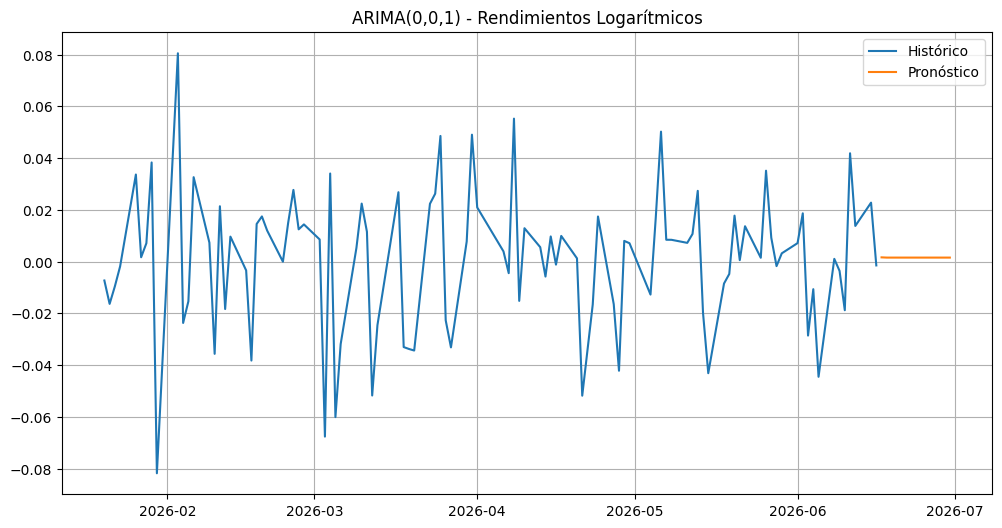

In [53]:
# Ajustar modelo
modelo = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,1))
resultado = modelo.fit()

# Pronóstico de 30 días
n_periodos = 10
forecast = resultado.forecast(steps=n_periodos)

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df.index[-100:],
         df['Rendimientos_Log'].iloc[-100:],
         label='Histórico')

plt.plot(
    pd.date_range(df.index[-1], periods=n_periodos+1, freq='B')[1:],
    forecast,
    label='Pronóstico'
)

plt.title('ARIMA(0,0,1) - Rendimientos Logarítmicos')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
forecast = resultado.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [55]:
ultimo_precio = df['Close'].iloc[-1]

In [56]:
precios_pronosticados = [ultimo_precio]

for r in forecast:
    nuevo_precio = precios_pronosticados[-1] * np.exp(r)
    precios_pronosticados.append(nuevo_precio)

precios_pronosticados = precios_pronosticados[1:]

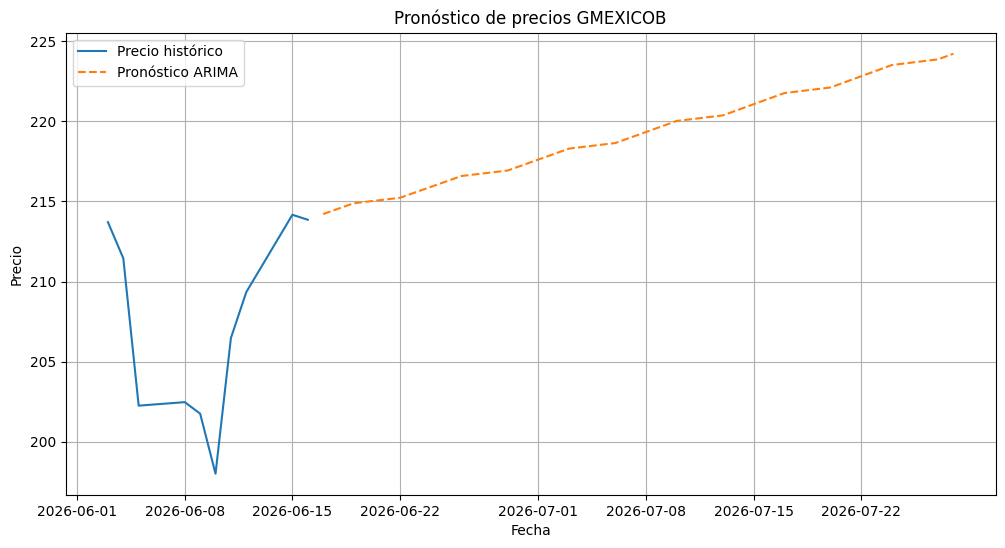

In [57]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index[-10:],
    df['Close'].iloc[-10:],
    label='Precio histórico'
)

fechas_futuras = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'
)[1:]

plt.plot(
    fechas_futuras,
    precios_pronosticados,
    label='Pronóstico ARIMA',
    linestyle='--'
)

plt.title('Pronóstico de precios GMEXICOB')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
#Comparar contra datos reales

# Serie de rendimientos
serie = df['Rendimientos_Log'].dropna()

# Entrenamiento y prueba
train = serie[:-101]
test = serie[-101:]

In [59]:
print(len(train))
print(len(test))

511
101


In [60]:
modelo = ARIMA(train, order=(0,0,1))
resultado = modelo.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [61]:
forecast_rend = resultado.forecast(steps=101)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [62]:
precios_reales = df['Close'].loc[test.index]

In [63]:
precio_inicial = df['Close'].loc[train.index[-1]]

precios_pred = [precio_inicial]

for r in forecast_rend:
    precios_pred.append(precios_pred[-1] * np.exp(r))

precios_pred = precios_pred[1:]

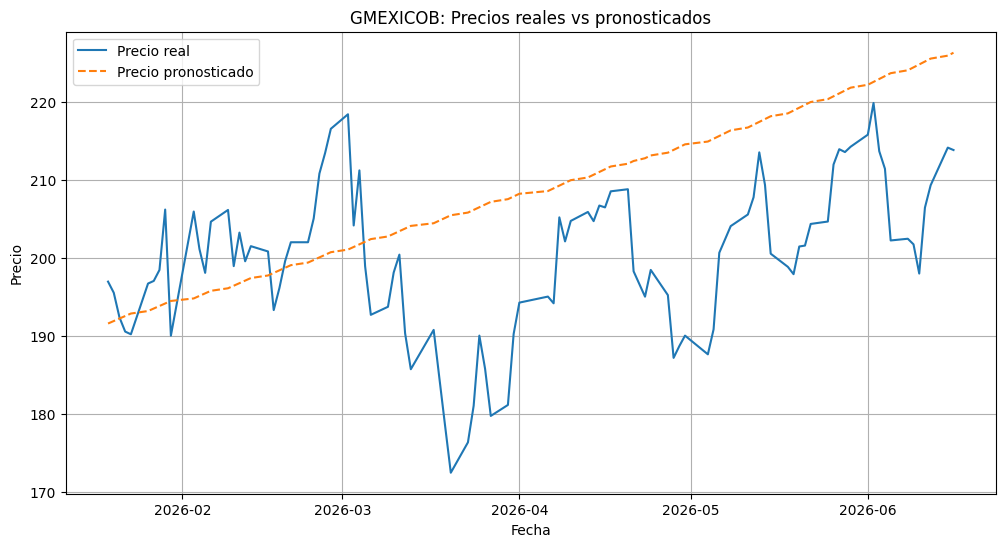

In [64]:
plt.figure(figsize=(12,6))

plt.plot(
    precios_reales.index,
    precios_reales.values,
    label='Precio real'
)

plt.plot(
    precios_reales.index,
    precios_pred,
    '--',
    label='Precio pronosticado'
)

plt.title('GMEXICOB: Precios reales vs pronosticados')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

##RMSE

In [65]:
rmse = np.sqrt(mean_squared_error(precios_reales, precios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 14.34


##MAE

In [66]:
mae = mean_absolute_error(precios_reales, precios_pred)
print(f"MAE = {mae: .2f}")

MAE =  11.87


##Error Porcentual Absoluto Medio (MAPE)

In [67]:
# Using scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(precios_reales, precios_pred) * 100
print(mape)

6.049935371205151


##Auto Arima

In [68]:
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,1)(0,0,0)[0] intercept


#Monte Carlo

In [69]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
2024-01-10   -0.015367
                ...   
2026-06-10   -0.018762
2026-06-11    0.041888
2026-06-12    0.013805
2026-06-15    0.022810
2026-06-16   -0.001448
Name: Rendimientos_Log, Length: 612, dtype: float64


In [70]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -26.9650
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [71]:
media_retornos = retornos.mean()
print(f"La media de los retornos es: {media_retornos:.6f}")

La media de los retornos es: 0.001577


In [72]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(f"La desviación de los retornos es: {desviacion_retornos:.6f}")

La desviación de los retornos es: 0.022221


In [73]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [74]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 213.86000061035156


In [75]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [76]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

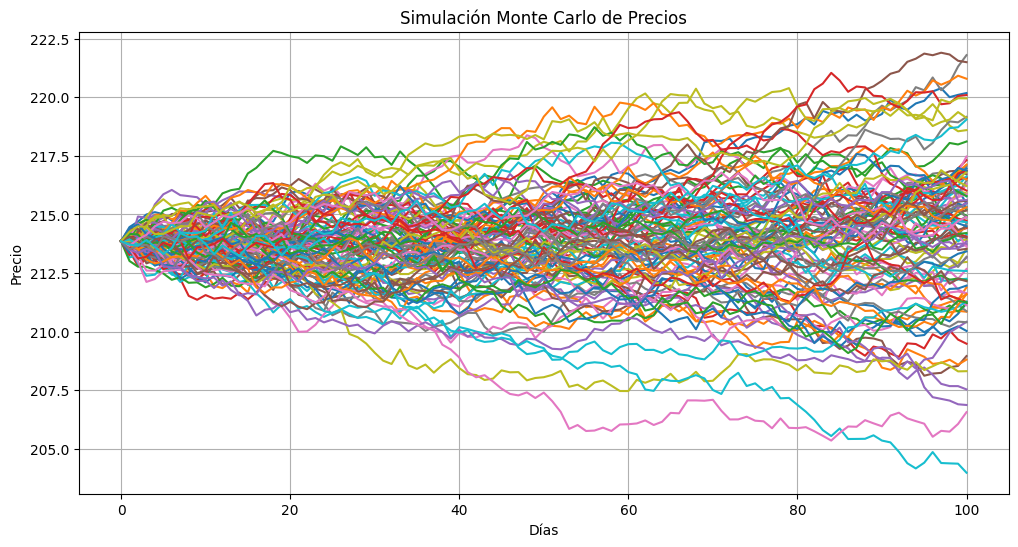

In [77]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [78]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [79]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      213.860001
1      213.710518
2      213.669556
3      213.912482
4      213.616471
          ...    
96     218.155622
97     218.343566
98     218.681915
99     218.721702
100    219.049627
Name: 99, Length: 101, dtype: float64


In [80]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  196.96


/tmp/ipykernel_18482/3328606284.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [81]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [82]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

         0          1          2          3          4          5    \
0  16.895386  16.745903  16.704941  16.947867  16.651856  16.354064   

         6          7          8         9    ...        91         92   \
0  16.599636  17.242918  17.074151  17.10139  ...  20.747714  20.653139   

         93         94         95         96         97       98         99   \
0  21.256393  21.430688  21.232934  21.191007  21.378951  21.7173  21.757087   

         100  
0  22.085012  

[1 rows x 101 columns]


In [83]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [84]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .2f}")

Ganancia Potencial: $  18.43


In [85]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .2f}")

Precio Potencial: $  215.39


##Error Cuadrático Medio (RMSE)


In [86]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [87]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [88]:
ultimos_101 = precios.iloc[-103:-2]
print(ultimos_101)

Date
2026-01-15    191.682541
2026-01-16    191.189804
2026-01-19    196.964615
2026-01-20    195.535690
2026-01-21    192.372360
                 ...    
2026-06-08    202.470001
2026-06-09    201.750000
2026-06-10    198.000000
2026-06-11    206.470001
2026-06-12    209.339996
Name: Close, Length: 101, dtype: float64


In [89]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [90]:
rmse = np.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 17.1248


In [91]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 8.5808 %


##Error Cuadrático Medio (MAE)

In [92]:
mae = mean_absolute_error(ultimos_101, prediccion_mc)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 14.5507


##Error Porcentual Absoluto Medio (MAPE)

In [93]:
# Using numpy
mape = np.mean(np.absolute((ultimos_101 - prediccion_mc) / ultimos_101)) * 100
print(mape)

nan


/tmp/ipykernel_18482/475056635.py:2: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.absolute((ultimos_101 - prediccion_mc) / ultimos_101)) * 100


In [94]:
# Using scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(ultimos_101, prediccion_mc) * 100
print(mape)

7.5284797151392056
